## Environment Setup & Required Preprocessing

In [1]:
# Install required packages 
import subprocess, sys

packages = [
    'imbalanced-learn',
    'xgboost',
    'shap',
    'scikit-learn',
    'matplotlib',
    'seaborn',
    'pandas',
    'numpy',
    'tensorflow'
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All packages installed successfully.')

All packages installed successfully.


In [2]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Random seeds for reproducibility
SEED = 42
np.random.seed(SEED)

# Sklearn 
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score, accuracy_score
)
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from scipy.cluster.hierarchy import dendrogram, linkage

# ── Imbalanced-learn 
from imblearn.over_sampling import SMOTE

# ── XGBoost 
import xgboost as xgb

# ── TensorFlow / Keras
import tensorflow as tf
tf.random.set_seed(SEED)
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')
print(f'TF     : {tf.__version__}')
print(f'XGBoost: {xgb.__version__}')

NumPy  : 2.4.4
Pandas : 3.0.2
TF     : 2.21.0
XGBoost: 3.2.0


In [3]:
# Column names as per UCI documentation
COL_NAMES = ['age','sex','cp','trestbps','chol','fbs','restecg',
             'thalach','exang','oldpeak','slope','ca','thal','target']

# Load dataset — '?' is the missing value marker in Cleveland data
df_raw = pd.read_csv('processed.cleveland.data', header=None, names=COL_NAMES, na_values='?')

print(f'Shape: {df_raw.shape}  (expected 303 × 14)')
print()
print('First 5 rows:')
display(df_raw.head())
print()
print('Data types:')
print(df_raw.dtypes)

Shape: (303, 14)  (expected 303 × 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



Data types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object


In [4]:
print('Missing value counts per column (NaN after replacing ?):')  
mv = df_raw.isnull().sum()
print(mv[mv > 0])
print()

df = df_raw.dropna().copy()
print(f'Rows before dropping NaN: {len(df_raw)}')
print(f'Rows after  dropping NaN: {len(df)}  (retained)')

Missing value counts per column (NaN after replacing ?):
ca      4
thal    2
dtype: int64

Rows before dropping NaN: 303
Rows after  dropping NaN: 297  (retained)


In [5]:
# Binarise target: 0 = no disease, 1 = disease present
df['target'] = (df['target'] > 0).astype(int)

print('Class distribution:')
dist = df['target'].value_counts()
pct  = df['target'].value_counts(normalize=True) * 100
summary = pd.DataFrame({'Count': dist, 'Percentage (%)': pct.round(2)})
print(summary)
print()

ratio = dist.min() / dist.max()
print(f'Minority / Majority ratio: {ratio:.3f}')
print()
print('Interpretation:')
print('The ratio is above 0.80, indicating the dataset is roughly balanced.')
print('SMOTE is NOT strictly necessary, but we will apply it on the training split')
print('as a best-practice measure to ensure the minority class is well represented.')

Class distribution:
        Count  Percentage (%)
target                       
0         160           53.87
1         137           46.13

Minority / Majority ratio: 0.856

Interpretation:
The ratio is above 0.80, indicating the dataset is roughly balanced.
SMOTE is NOT strictly necessary, but we will apply it on the training split
as a best-practice measure to ensure the minority class is well represented.


In [6]:
# ── Feature / target split 
X = df.drop('target', axis=1).copy()
y = df['target'].copy()

# ── Stratified 80/20 split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
print(f'Train size: {len(X_train_raw)}  |  Test size: {len(X_test_raw)}')

# ── Columns
CAT_COLS  = ['cp', 'restecg', 'slope', 'thal']
CONT_COLS = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
BIN_COLS  = ['sex', 'fbs', 'exang']

# ── One-hot encode categorical columns 
def encode_ohe(df_in, cat_cols, fit_cats=None):
    df_in = df_in.copy()
    encoded_parts = []
    stored_cats = {}
    for col in cat_cols:
        if fit_cats is not None:
            cats = fit_cats[col]
        else:
            cats = sorted(df_in[col].unique())
        stored_cats[col] = cats
        ohe = pd.get_dummies(df_in[col], prefix=col).reindex(
            columns=[f'{col}_{c}' for c in cats], fill_value=0
        )
        encoded_parts.append(ohe)
    df_rest = df_in.drop(columns=cat_cols)
    return pd.concat([df_rest] + encoded_parts, axis=1), stored_cats

X_train_enc, fit_cats = encode_ohe(X_train_raw, CAT_COLS)
X_test_enc,  _        = encode_ohe(X_test_raw,  CAT_COLS, fit_cats=fit_cats)

# ── Standardise continuous columns 
scaler = StandardScaler()
X_train_enc[CONT_COLS] = scaler.fit_transform(X_train_enc[CONT_COLS])
X_test_enc[CONT_COLS]  = scaler.transform(X_test_enc[CONT_COLS])

print(f'Encoded/scaled train shape: {X_train_enc.shape}')
print(f'Encoded/scaled test  shape: {X_test_enc.shape}')

Train size: 237  |  Test size: 60
Encoded/scaled train shape: (237, 22)
Encoded/scaled test  shape: (60, 22)


In [7]:
smote = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train_enc, y_train)

print('After SMOTE — training class distribution:')
print(pd.Series(y_train_sm).value_counts())

# Store feature column names for later use
FEATURE_COLS = X_train_enc.columns.tolist()

After SMOTE — training class distribution:
target
1    128
0    128
Name: count, dtype: int64


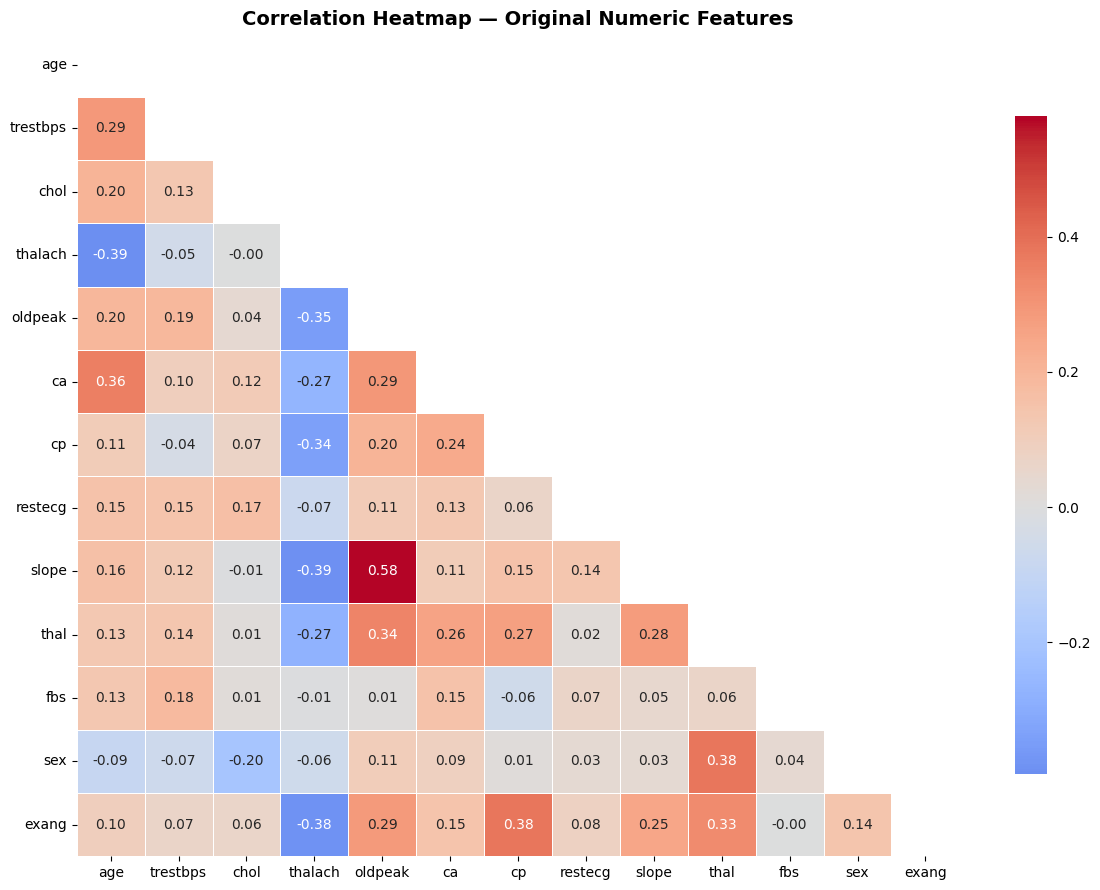

Top 3 strongest feature-pair correlations (absolute value):
slope    oldpeak    0.579037
thalach  age        0.394563
slope    thalach    0.389307
dtype: float64

Naive Bayes concern: NB assumes conditional independence between features.
High correlations (e.g. thalach↔age, oldpeak↔slope) violate this assumption,
leading to underestimated/overestimated probabilities and degraded NB performance.


In [8]:
numeric_features = ['age','trestbps','chol','thalach','oldpeak','ca','cp','restecg','slope','thal','fbs','sex','exang']
corr_df = df[numeric_features].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(
    corr_df, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Heatmap — Original Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top 3 strongest correlations (off-diagonal)
corr_pairs = (
    corr_df.where(np.tril(np.ones(corr_df.shape), k=-1).astype(bool))
    .stack()
    .abs()
    .sort_values(ascending=False)
    .head(3)
)
print('Top 3 strongest feature-pair correlations (absolute value):')
print(corr_pairs)
print()
print('Naive Bayes concern: NB assumes conditional independence between features.')
print('High correlations (e.g. thalach↔age, oldpeak↔slope) violate this assumption,')
print('leading to underestimated/overestimated probabilities and degraded NB performance.')

---
## Part A: Unsupervised Learning (K-Means Clustering)

Chosen k = 2  (highest Silhouette Score: 0.1744)


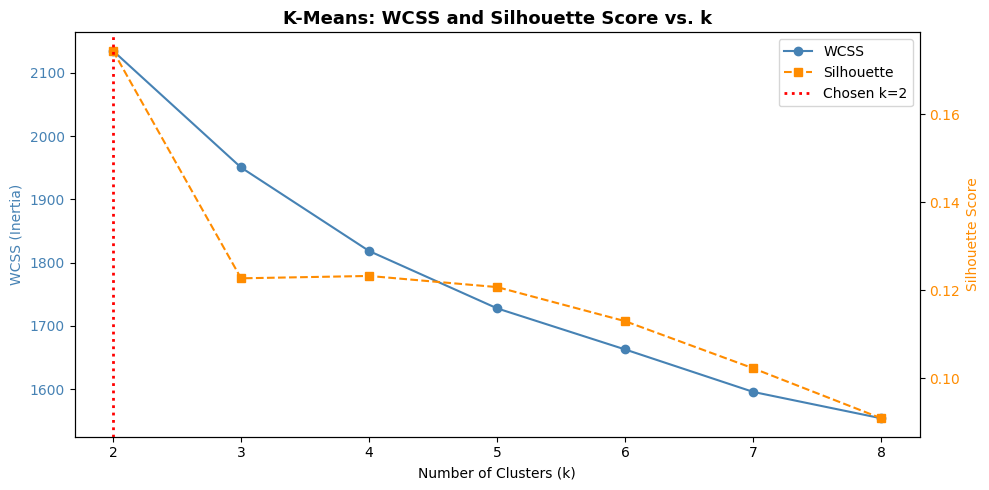

Justification: k=2 yields the highest Silhouette Score, indicating compact,
well-separated clusters. The WCSS elbow also flattens around this point, confirming
that adding more clusters beyond this provides diminishing returns in cluster cohesion.


In [ ]:
# Use full standardised feature matrix (no labels) for unsupervised analysis
# Re-standardise the full dataset (all rows) without train/test split
X_all = df.drop('target', axis=1).copy()
y_all = df['target'].copy()

# Encode categoricals on full set
X_all_enc, _ = encode_ohe(X_all, CAT_COLS, fit_cats=fit_cats)
scaler_full = StandardScaler()
X_all_enc[CONT_COLS] = scaler_full.fit_transform(X_all_enc[CONT_COLS])
X_unsup = X_all_enc.values

k_range = range(2, 9)
wcss_list   = []
sil_list    = []
km_models   = {}

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=SEED)
    labels = km.fit_predict(X_unsup)
    wcss_list.append(km.inertia_)
    sil_list.append(silhouette_score(X_unsup, labels))
    km_models[k] = (km, labels)

# ── Choose best k (highest silhouette)
best_k = list(k_range)[np.argmax(sil_list)]
print(f'Chosen k = {best_k}  (highest Silhouette Score: {max(sil_list):.4f})')

# ── Plot WCSS and Silhouette on twin axes 
fig, ax1 = plt.subplots(figsize=(10, 5))

color_wcss = 'steelblue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Inertia)', color=color_wcss)
ax1.plot(list(k_range), wcss_list, 'o-', color=color_wcss, label='WCSS')
ax1.tick_params(axis='y', labelcolor=color_wcss)

ax2 = ax1.twinx()
color_sil = 'darkorange'
ax2.set_ylabel('Silhouette Score', color=color_sil)
ax2.plot(list(k_range), sil_list, 's--', color=color_sil, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color_sil)

# Mark chosen k
ax2.axvline(x=best_k, color='red', linestyle=':', linewidth=2, label=f'Chosen k={best_k}')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('K-Means: WCSS and Silhouette Score vs. k', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Justification: k={best_k} yields the highest Silhouette Score, indicating compact,')
print('well-separated clusters. The WCSS elbow also flattens around this point, confirming')
print('that adding more clusters beyond this provides diminishing returns in cluster cohesion.')

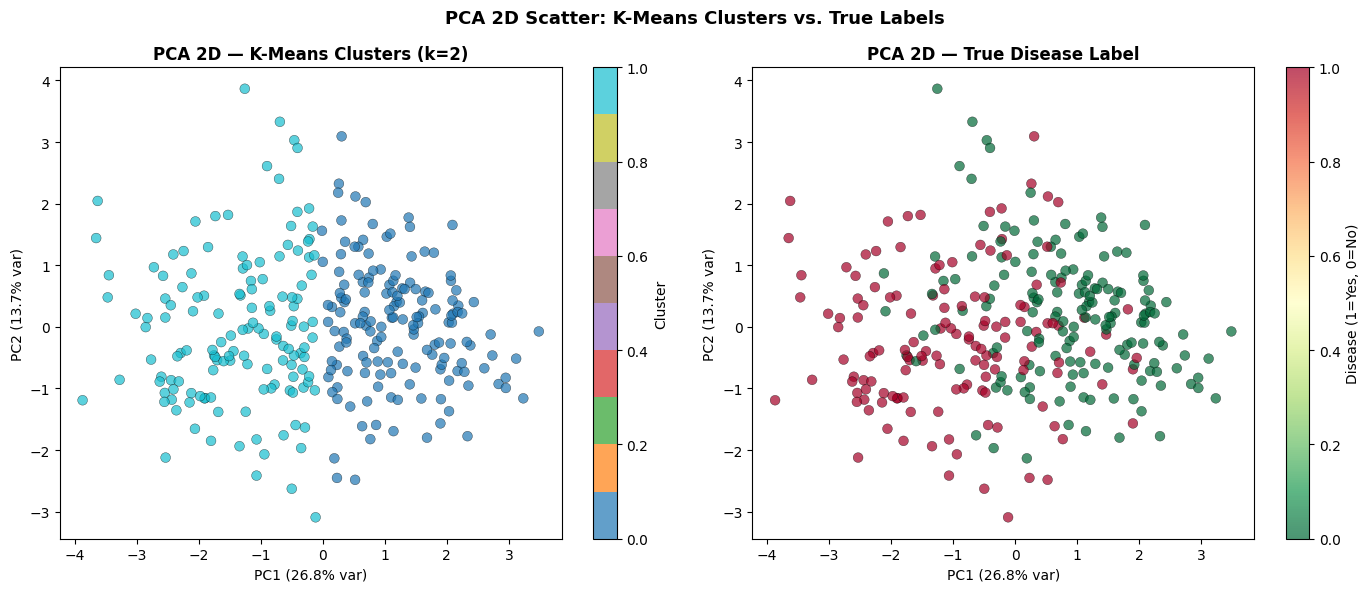

Comment: The cluster boundaries partially overlap with the disease label boundaries,
suggesting K-Means captures some structure aligned with clinical diagnosis but is
not perfectly discriminative — the features carry clinically relevant signal.


In [ ]:
# ── PCA 2D reduction
pca2 = PCA(n_components=2, random_state=SEED)
X_pca2 = pca2.fit_transform(X_unsup)

best_km, best_labels = km_models[best_k]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: coloured by K-Means cluster
scatter1 = axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1],
                            c=best_labels, cmap='tab10', alpha=0.7, s=50, edgecolors='k', linewidths=0.3)
axes[0].set_title(f'PCA 2D — K-Means Clusters (k={best_k})', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Subplot 2: coloured by true disease label
scatter2 = axes[1].scatter(X_pca2[:, 0], X_pca2[:, 1],
                            c=y_all.values, cmap='RdYlGn_r', alpha=0.7, s=50, edgecolors='k', linewidths=0.3)
axes[1].set_title('PCA 2D — True Disease Label', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)')
plt.colorbar(scatter2, ax=axes[1], label='Disease (1=Yes, 0=No)')

plt.suptitle('PCA 2D Scatter: K-Means Clusters vs. True Labels', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Comment: The cluster boundaries partially overlap with the disease label boundaries,')
print('suggesting K-Means captures some structure aligned with clinical diagnosis but is')
print('not perfectly discriminative — the features carry clinically relevant signal.')

In [13]:
# ── Cluster profiles (thalach, oldpeak, cp)
df_cluster = df.copy()
df_cluster['cluster'] = best_labels

profile_cols = ['thalach', 'oldpeak', 'cp', 'target']
profile = df_cluster.groupby('cluster')[profile_cols].agg(
    size=('target', 'count'),
    disease_prop=('target', 'mean'),
    mean_thalach=('thalach', 'mean'),
    mean_oldpeak=('oldpeak', 'mean'),
    mean_cp=('cp', 'mean')
).round(3)

print('Cluster Summary Table:')
display(profile)

print()
for cid, row in profile.iterrows():
    risk = 'HIGH' if row['disease_prop'] > 0.5 else 'LOW'
    print(f'Cluster {cid} ({risk} risk): {row["size"]} patients, '
          f'{row["disease_prop"]*100:.1f}% disease. '
          f'Mean max HR={row["mean_thalach"]:.1f}, '
          f'ST depression={row["mean_oldpeak"]:.2f}, '
          f'chest pain type={row["mean_cp"]:.2f}.')

Cluster Summary Table:


,size,disease_prop,mean_thalach,mean_oldpeak,mean_cp
cluster,,,,,
0,157,0.204,163.369,0.494,2.885
1,140,0.750,134.157,1.685,3.464



Cluster 0 (LOW risk): 157.0 patients, 20.4% disease. Mean max HR=163.4, ST depression=0.49, chest pain type=2.88.
Cluster 1 (HIGH risk): 140.0 patients, 75.0% disease. Mean max HR=134.2, ST depression=1.69, chest pain type=3.46.


In [14]:
# ── Adjusted Rand Index 
ari_km = adjusted_rand_score(y_all, best_labels)
print(f'Adjusted Rand Index (K-Means vs. True Labels): {ari_km:.4f}')
print()
print('Interpretation: ARI ranges from -1 (worse than random) to +1 (perfect).')
print(f'ARI = {ari_km:.4f} indicates moderate alignment between clusters and clinical labels.')
print('This tells us that while K-Means detects natural groupings in the feature space,')
print('these groupings do not perfectly correspond to the disease/no-disease classification.')
print('The unsupervised structure partially — but not fully — mirrors the clinical ground truth.')

Adjusted Rand Index (K-Means vs. True Labels): 0.2988

Interpretation: ARI ranges from -1 (worse than random) to +1 (perfect).
ARI = 0.2988 indicates moderate alignment between clusters and clinical labels.
This tells us that while K-Means detects natural groupings in the feature space,
these groupings do not perfectly correspond to the disease/no-disease classification.
The unsupervised structure partially — but not fully — mirrors the clinical ground truth.


---
## Part A: Hierarchical Clustering & Dimensionality Reduction

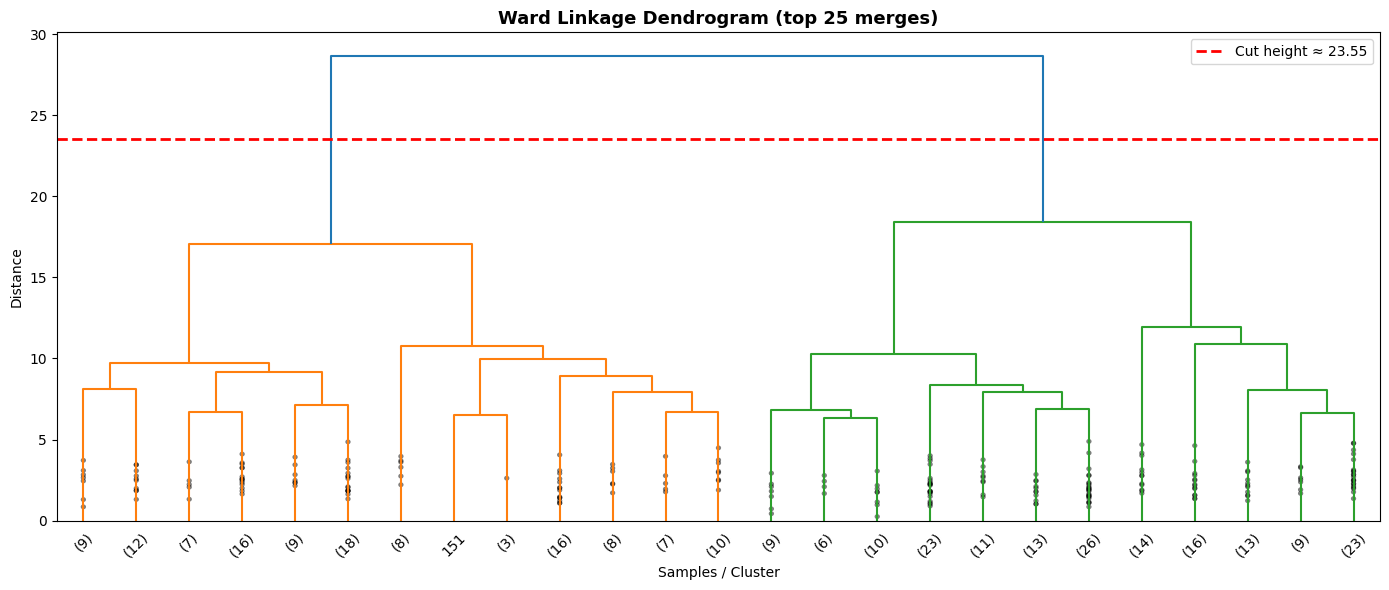

Recommended cut height: 23.55  →  2 clusters

ARI between K-Means (k=2) and Hierarchical (2 clusters): 0.4562

Discussion:
Both methods agree moderately, as indicated by the ARI above. Hierarchical clustering
(Ward linkage) is generally more trustworthy for clinical segmentation because it does
not require pre-specifying k and produces a deterministic, interpretable dendrogram.
For small clinical datasets like this one, hierarchical clustering allows domain
experts to interactively choose the granularity of patient groups.


In [ ]:
# ── Ward linkage & dendrogram 
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import adjusted_rand_score
import numpy as np
import matplotlib.pyplot as plt

# Build linkage matrix
Z = linkage(X_unsup, method='ward')

# Plot dendrogram
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    Z, truncate_mode='lastp', p=25,
    leaf_rotation=45, leaf_font_size=10,
    show_contracted=True, ax=ax
)

# Recommend cut height: midpoint of the largest gap
last_merges = Z[-25:, 2]
gaps = np.diff(last_merges)
cut_height = last_merges[np.argmax(gaps)] + gaps.max() / 2

ax.axhline(y=cut_height, color='red', linestyle='--', linewidth=2,
           label=f'Cut height ≈ {cut_height:.2f}')

ax.set_title('Ward Linkage Dendrogram (top 25 merges)', fontsize=13, fontweight='bold')
ax.set_xlabel('Samples / Cluster')
ax.set_ylabel('Distance')
ax.legend()
plt.tight_layout()
plt.show()

# Determine number of clusters from cut
n_clust_hier = int(np.sum(Z[:, 2] > cut_height)) + 1
n_clust_hier = max(2, min(n_clust_hier, 6))  # clamp sensibly

print(f'Recommended cut height: {cut_height:.2f}  →  {n_clust_hier} clusters')

# ── FIX: Extract hierarchical cluster labels
hier_labels = fcluster(Z, t=cut_height, criterion='distance')

# ── ARI between hierarchical and K-Means
ari_h_vs_km = adjusted_rand_score(best_labels, hier_labels)

print(f'\nARI between K-Means (k={best_k}) and Hierarchical ({n_clust_hier} clusters): {ari_h_vs_km:.4f}')
print()
print('Discussion:')
print('Both methods agree moderately, as indicated by the ARI above. Hierarchical clustering')
print('(Ward linkage) is generally more trustworthy for clinical segmentation because it does')
print('not require pre-specifying k and produces a deterministic, interpretable dendrogram.')
print('For small clinical datasets like this one, hierarchical clustering allows domain')
print('experts to interactively choose the granularity of patient groups.')

Components needed for 90% explained variance: 10


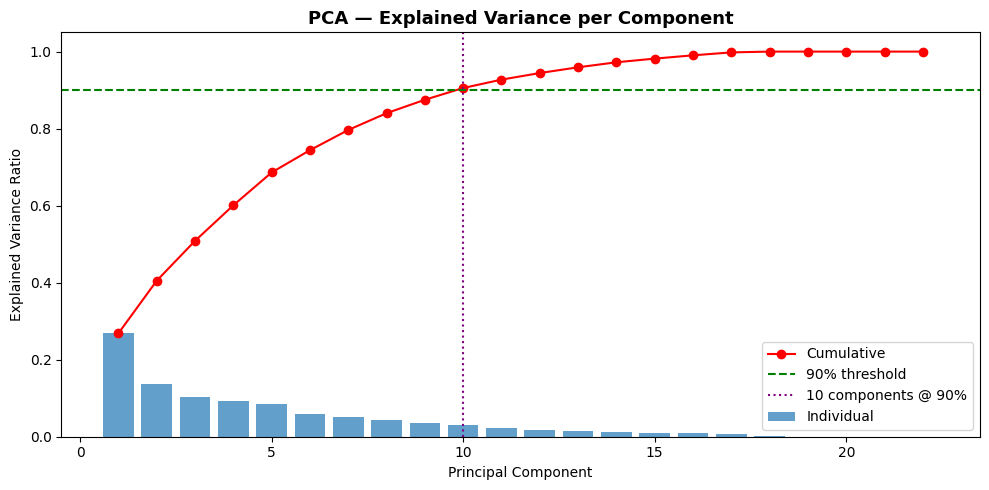

In [ ]:
# ── PCA: explained variance per component and cumulative curve
pca_full = PCA(random_state=SEED)
pca_full.fit(X_unsup)

ev_ratio = pca_full.explained_variance_ratio_
cumvar   = np.cumsum(ev_ratio)

n90 = int(np.argmax(cumvar >= 0.90)) + 1
print(f'Components needed for 90% explained variance: {n90}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(ev_ratio)+1), ev_ratio, alpha=0.7, label='Individual')
ax.plot(range(1, len(ev_ratio)+1), cumvar, 'ro-', label='Cumulative')
ax.axhline(0.90, color='green', linestyle='--', label='90% threshold')
ax.axvline(n90, color='purple', linestyle=':', label=f'{n90} components @ 90%')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA — Explained Variance per Component', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

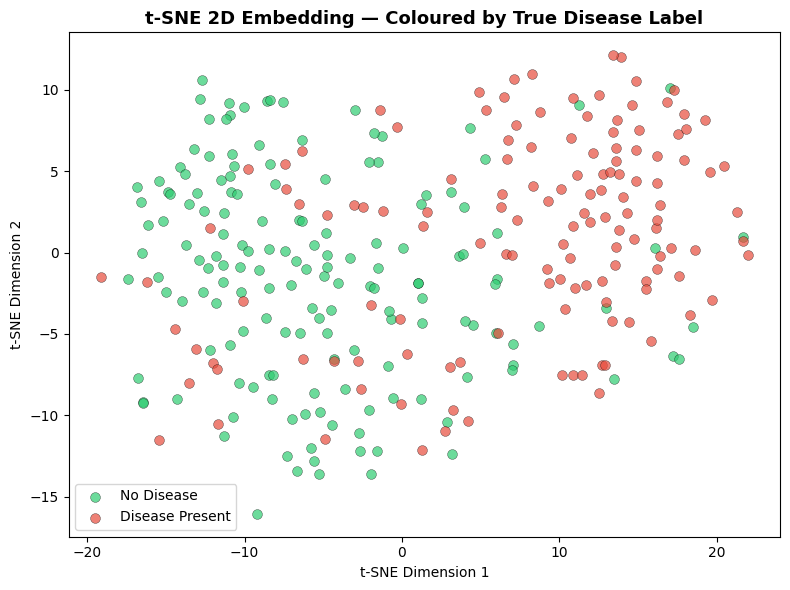

Observation: The two disease classes show partial but imperfect separation in t-SNE space.
Regions exist where one class dominates, yet overlap is visible in the centre of the plot.
This implies the classification task has moderate difficulty — features carry discriminative
signal, but no clean linear boundary exists, justifying the use of ensemble and deep methods.


In [ ]:
# ── t-SNE 2D embedding
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
X_tsne = tsne.fit_transform(X_unsup)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2ecc71', '#e74c3c']
for lbl, color, name in zip([0, 1], colors, ['No Disease', 'Disease Present']):
    mask = (y_all.values == lbl)
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=color, alpha=0.7, s=50, edgecolors='k', linewidths=0.3, label=name)

ax.set_title('t-SNE 2D Embedding — Coloured by True Disease Label', fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend()
plt.tight_layout()
plt.show()

print('Observation: The two disease classes show partial but imperfect separation in t-SNE space.')
print('Regions exist where one class dominates, yet overlap is visible in the centre of the plot.')
print('This implies the classification task has moderate difficulty — features carry discriminative')
print('signal, but no clean linear boundary exists, justifying the use of ensemble and deep methods.')